# Boosting Techniques — Assignment





---



## Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.

**Answer (Long):**

**Definition and intuition**  
Boosting is an ensemble learning technique that combines multiple **weak learners** (models that perform slightly better than random guessing) to produce a single **strong learner** with high predictive performance. The central idea is to train learners sequentially, where each new learner focuses on the mistakes (errors) made by the previous learners. By giving more attention (higher weight) to difficult-to-predict examples, boosting forms a composite model that corrects earlier errors.

**How boosting improves weak learners (step-by-step intuition)**  
1. **Sequential training**: Instead of training models independently (as in bagging), boosting trains a model, measures where it made errors, then trains the next model to correct those errors. This sequential emphasis helps the ensemble reduce bias.  
2. **Weighted emphasis on hard examples**: Examples misclassified by previous learners are given greater importance, forcing subsequent learners to focus on them. Over iterations, hard-to-predict samples receive progressively higher weights.  
3. **Model combination**: Each weak learner is assigned a weight based on its accuracy (or another performance metric). The final prediction is a weighted combination (e.g., weighted sum or vote) of all learners. Good learners contribute more to the final output.  
4. **Error-correcting behavior**: Because each learner is specialized to handle errors left by prior ones, the ensemble can approximate complex functions even if each base model is simple (like shallow decision trees).

**Formal view**  
Boosting can be understood as a stagewise greedy optimization of a loss function (e.g., exponential loss for AdaBoost or squared error for gradient boosting). In this view, each successive weak learner fits the negative gradient (residuals) of the loss function with respect to the current ensemble prediction — hence the name **Gradient Boosting**.

**Why weak learners are ideal base models**  
Weak learners (often decision stumps or shallow trees) are:  
- **Fast to train**, enabling many boosting iterations.  
- **Low-variance** individually, which helps the ensemble avoid overfitting early on.  
- **Combinable**, because their systematic mistakes can be corrected by later learners.

**Key benefits of boosting**  
- Substantial **reduction in bias**; often yields state-of-the-art results.  
- **Flexibility** with different loss functions and base learners.  
- **Robustness** when properly regularized (though unregularized boosting can overfit).

**Limitations**  
- Sensitive to **noisy labels** and outliers (since boosting focuses on hard-to-predict examples, it may overfit noise).  
- Can be **computationally expensive** for many iterations and large datasets.  
- Requires careful **regularization and early stopping** in practice.

**Common boosting algorithms**: AdaBoost, Gradient Boosting Machines (GBM), XGBoost, LightGBM, CatBoost.  


## Question 2: Difference between AdaBoost and Gradient Boosting in training

**Answer (Long):**

**High-level difference**  
- **AdaBoost (Adaptive Boosting)** changes the distribution (weights) on training examples. At each iteration, AdaBoost increases weights for misclassified examples and decreases weights for correctly classified ones; the next weak learner is trained on this weighted dataset. The final model is a weighted vote of the weak learners, where learners with lower error get higher influence.

- **Gradient Boosting** frames boosting as **function approximation** by **gradient descent in function space**. Each new learner is trained to predict the **residuals** (negative gradients) of a chosen differentiable loss function (e.g., mean squared error, logistic loss). The ensemble is updated by adding the new learner multiplied by a learning rate, effectively performing stagewise gradient descent.

**Algorithmic contrast (stepwise)**

- *AdaBoost*:
  1. Initialize equal weights for all training samples.
  2. Train weak learner \(h_t\) on weighted samples.
  3. Compute weighted error \(
arepsilon_t\).
  4. Compute learner weight \(lpha_t =
rac{1}{2}\ln\left(
rac{1 -
arepsilon_t}{
arepsilon_t}
ight)\).
  5. Update sample weights: increase for misclassified, decrease for correctly classified.
  6. Final prediction: sign of \(\sum_t lpha_t h_t(x)\).

- *Gradient Boosting*:
  1. Initialize model \(F_0(x)\) (e.g., predict average label or log-odds).
  2. For each iteration \(t\):
     - Compute negative gradient (residuals) \(r_{i,t} = -\left.
rac{\partial L(y_i, F(x_i))}{\partial F(x_i)}
ight|_{F=F_{t-1}}\).
     - Fit weak learner \(h_t(x)\) to the residuals \(r_{i,t}\).
     - Find multiplier (step size) \(\gamma_t\) (via line search or analytic solution).
     - Update \(F_t(x) = F_{t-1}(x) + \eta \gamma_t h_t(x)\) where \(\eta\) is the learning rate.

**Practical differences**
- **Loss flexibility**: Gradient boosting can use any differentiable loss; AdaBoost is typically tied to exponential loss (classification).  
- **Weighting vs residual fitting**: AdaBoost modifies sample weights; gradient boosting fits residuals directly.  
- **Interpretability of updates**: Gradient boosting updates are additive function approximations and connect to gradient descent theory.  
- **Robustness & tuning**: Gradient boosting provides explicit learning rate, subsampling options, and more direct ways to regularize; AdaBoost is simpler but can be sensitive to noisy labels.

**When to prefer each**  
- AdaBoost: simple baseline for binary classification with clean data.  
- Gradient Boosting (and its improved implementations like XGBoost/LightGBM/CatBoost): preferred for flexible loss functions, regression, or when strong performance and fine control are needed.


## Question 3: How does regularization help in XGBoost?

**Answer (Long):**

XGBoost (Extreme Gradient Boosting) includes several regularization techniques designed to reduce overfitting and improve generalization. Regularization helps by penalizing model complexity and preventing the trees from fitting noise.

**Forms of regularization in XGBoost**

1. **L1 (Lasso) regularization on leaf weights (`alpha`)**  
   - Adds absolute-value penalty \(lpha \sum |w_j|\) on leaf weights.  
   - Encourages sparsity in the weights—small contributing leaves can be driven to zero—helpful for feature selection and simpler models.

2. **L2 (Ridge) regularization on leaf weights (`lambda`)**  
   - Adds squared penalty \(\lambda \sum w_j^2\).  
   - Stabilizes the learning process and reduces variance by shrinking leaf weights.

3. **Tree complexity penalty (`gamma`)**  
   - Minimum loss reduction required to make a split. Larger `gamma` requires larger gain for a split, producing shallower trees and preventing small, unhelpful splits.

4. **Max depth (`max_depth`) and min child weight (`min_child_weight`)**  
   - `max_depth` limits tree depth (controls model complexity).  
   - `min_child_weight` prevents creating leaves where the sum of instance weight is too small.

5. **Subsampling (`subsample`, `colsample_bytree`, `colsample_bylevel`, `colsample_bynode`)**  
   - Randomly sample rows and/or columns when building trees. Acts like bagging inside boosting: reduces correlation between trees and helps prevent overfitting.

6. **Learning rate (`eta`)**  
   - Shrinks contribution of each tree by a factor `eta` (0 < eta ≤ 1). Smaller learning rates with more trees often generalize better.

7. **Early stopping**  
   - Monitor validation loss and stop when performance stops improving. Prevents overfitting in later iterations.

**Why these help**  
- Regularization balances bias-variance trade-off: by penalizing complexity (deep trees, large weights), XGBoost reduces variance and avoids fitting noise.  
- Subsampling and column sampling reduce tree correlations and make the ensemble more robust.  
- L1/L2 penalties keep leaf weights small and the model smoother.

**Practical tip**  
Combine several regularization strategies (e.g., smaller `eta`, modest `max_depth`, `lambda`/`alpha` tuning, and early stopping) to get robust performance. Use cross-validation (e.g., `cv` in xgboost or `GridSearchCV`) to find the best set of regularization hyperparameters.


## Question 4: Why is CatBoost considered efficient for handling categorical data?

**Answer (Long):**

CatBoost (Categorical Boosting) was designed to handle categorical features natively and efficiently, avoiding extensive preprocessing while reducing target leakage and overfitting. Here’s why CatBoost is particularly well-suited:

**Key innovations for categorical data**

1. **Ordered Target Statistics (Ordered Target Encoding)**  
   - Standard target encoding (e.g., replacing category with mean target) can leak information because encoding uses the whole training target distribution. CatBoost uses **ordered target statistics** that compute the encoding for each example using only preceding data in a randomized permutation of the dataset. This reduces target leakage and produces more robust encodings.

2. **Efficient handling of high-cardinality features**  
   - CatBoost uses algorithms that split categories into groups and creates combinations smartly, reducing the explosion of features common in one-hot encodings for high-cardinality categorical variables.

3. **Permutation-driven approach**  
   - CatBoost trains multiple permutations and uses statistics derived from them which reduces overfitting and makes encodings less likely to memorize the data.

4. **Native categorical feature support**  
   - You pass categorical feature indices directly to the CatBoost model; it internally applies its encoding and special split strategies designed for categorical variables. This avoids manual preprocessing and potential mistakes.

5. **Robust default hyperparameters and symmetric trees**  
   - CatBoost builds symmetric trees (same split structure across levels), which can be faster and more regularized. The defaults are tuned to work well on many datasets, particularly those with many categorical features.

**Practical advantages**

- Saves preprocessing effort (no need for manual one-hot or label encoding).  
- Less prone to target leakage compared to naive target encoding methods.  
- Often gives better performance out-of-the-box on datasets with many categorical features.  
- Handles categorical interactions more intelligently.

**Limitations**  
- CatBoost's internals can be more complex; in some rare cases, a well-engineered manual encoding might match or outperform it.  
- Training time can be larger on very large datasets if many permutations and complex encodings are used, but CatBoost provides options to balance speed and accuracy.


## Question 5: Real-world applications where boosting is preferred over bagging

**Answer (Long):**

Boosting algorithms (AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost) often outperform bagging-based methods (like Random Forests) in many real-world applications when high predictive accuracy is required and when careful tuning is possible. Example domains:

1. **Finance & Risk Modeling**  
   - Credit scoring, fraud detection, loan default prediction: boosting models capture complex nonlinear relationships and interactions from customer features, improving detection rates and ranking. Their ability to handle imbalanced classes with appropriate loss functions and sampling strategies is valuable.

2. **Search Ranking & Recommendation Systems**  
   - Learning-to-rank and personalized recommendation tasks often use gradient-boosted decision trees (GBDTs) because they can directly optimize ranking losses and capture complex user-item interactions.

3. **Ad Click-Through Rate (CTR) Prediction**  
   - Boosted trees (e.g., LightGBM, XGBoost) are commonly used in industry for CTR and conversion prediction due to high accuracy, handling of categorical features, and speed (especially LightGBM).

4. **Customer Churn and Marketing**  
   - Predicting churn or customer lifetime value benefits from boosting’s ability to improve weak signals and model subtle patterns in transactional and demographic data.

5. **Healthcare & Bioinformatics**  
   - Disease outcome prediction, survival analysis, and genomics: boosting can combine weak predictors to form accurate risk stratification models.

6. **Insurance & Actuarial Modeling**  
   - Pricing, claim prediction, and fraud detection where sophisticated interactions and heteroskedasticity exist.

7. **Industrial & Manufacturing**  
   - Predictive maintenance, defect detection, and process optimization often favor boosting because of high accuracy on tabular data.

**Why boosting is chosen over bagging**  
- **Better bias reduction**: Boosting focuses on correcting errors, thereby reducing bias more effectively.  
- **Superior performance on tabular data**: On many tabular datasets, boosting methods (especially XGBoost/LightGBM/CatBoost) routinely outperform Random Forests in competitions and industry tasks.  
- **Flexibility with loss functions**: Boosting can optimize custom, differentiable loss functions for specific business objectives.  
- **Feature interactions**: Boosted trees capture feature interactions implicitly, enabling strong modeling of complex relationships.

**When bagging might still be preferred**  
- When you need faster training with less hyperparameter tuning, Random Forests are simpler and more robust to noisy labels. If interpretability and stability with noisy/outlier-heavy data are crucial, bagging sometimes offers an advantage.


In [2]:
# Install libraries if needed (uncomment & run in Colab)
# !pip install xgboost catboost seaborn matplotlib scikit-learn
print("If running in Colab, uncomment the pip install command and run this cell to install packages.")

If running in Colab, uncomment the pip install command and run this cell to install packages.


# Question 6: Train AdaBoost Classifier on Breast Cancer dataset and print accuracy

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Base estimator
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# ✅ Use 'estimator' instead of 'base_estimator'
adb = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, learning_rate=0.5, random_state=42)
adb.fit(X_train, y_train)

# Predict
y_pred = adb.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"AdaBoost Accuracy on breast cancer dataset: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


AdaBoost Accuracy on breast cancer dataset: 0.9561

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[38  4]
 [ 1 71]]


# Question 7: Train Gradient Boosting Regressor on California Housing dataset and evaluate R^2


In [4]:
# Question 7: Train Gradient Boosting Regressor on California Housing dataset and evaluate R^2

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load data
data = fetch_california_housing()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(X_train, y_train)

# Predict & evaluate
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Gradient Boosting R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

Gradient Boosting R^2: 0.8004
MSE: 0.2615


# Question 8: Train XGBoost Classifier on Breast Cancer dataset and tune learning_rate with GridSearchCV


In [5]:
# Question 8: Train XGBoost Classifier on Breast Cancer dataset and tune learning_rate with GridSearchCV

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost classifier (use GPU/CPU depending on environment)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Grid search over learning_rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 6]
}

grid = GridSearchCV(xgb, param_grid, scoring='accuracy', cv=4, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy on test set: {acc:.4f}")

Fitting 4 folds for each of 36 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:07:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
XGBoost Accuracy on test set: 0.9474


# Question 9: Train CatBoost Classifier and plot confusion matrix using seaborn

In [9]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [13]:
pip install seaborn


/tmp/ipython-input-31648266.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].astype(object).fillna('missing')
/tmp/ipython-input-31648266.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].astype(object).fillna('missing')


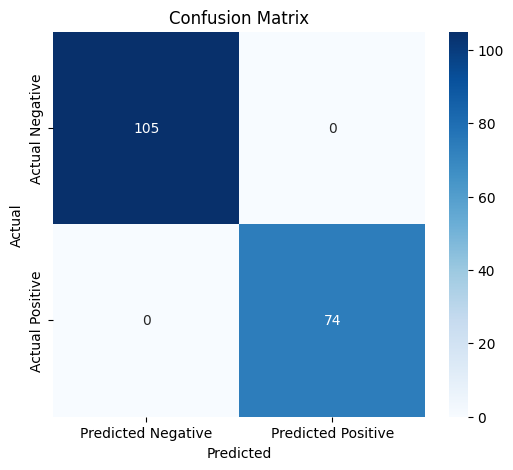

In [16]:
# Install required packages if missing:
# !pip install catboost seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier

# Load the Titanic example dataset from seaborn
data = sns.load_dataset('titanic')
target = 'survived'

# Separate features and target
X = data.drop(columns=[target])
y = data[target]

# Fill NaN values: numeric with 0, non-numeric with 'missing'
for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        X[col] = X[col].fillna(0)
    else:
        # Convert to object dtype first to allow adding 'missing' as a new string value
        X[col] = X[col].astype(object).fillna('missing')

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True) # drop_first to avoid multicollinearity

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train CatBoost Classifier
# CatBoost can handle categorical features natively, but since we already one-hot encoded,
# we don't need to specify 'cat_features' for X.
# If we passed original X with mixed types, we would use cat_features param.
model = CatBoostClassifier(verbose=0, iterations=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Question 10: FinTech pipeline for predicting loan default (imbalanced dataset, missing values, numeric + categorical)

**Answer (Long + Detailed pipeline)**

### 1) Problem understanding
- **Objective**: Predict whether a customer will default on a loan (binary classification).  
- **Challenges**: Class imbalance (defaults are rarer), missing values, mixture of numeric and categorical features, potential concept drift, and regulatory/interpretability requirements.

---

### 2) Data preprocessing & handling missing/categorical values (step-by-step)

1. **Exploratory Data Analysis (EDA)**  
   - Check distributions, missingness patterns, outliers, correlations, and feature types.  
   - Identify categorical features and cardinality.

2. **Missing values**  
   - **Numeric**: Impute using median (robust) or use model-based imputation (e.g., KNNImputer or IterativeImputer) if relationships exist.  
   - **Categorical**: Impute with a special value `'Missing'` or frequent category. For high-cardinality categorical features, consider grouping rare categories into `'Other'`.

3. **Encoding categorical features**  
   - **CatBoost**: Pass categorical column indices directly; CatBoost applies ordered target statistics internally—recommended when many categoricals exist.  
   - **XGBoost / AdaBoost**: Use target encoding with care (use cross-validation-based or leave-one-out to avoid leakage) or one-hot for low-cardinality categories; use frequency encoding or hashing for high-cardinality features.

4. **Feature engineering**  
   - Create ratio features (e.g., debt-to-income), temporal features (days since last default), aggregate transactional features (sum over last N months), and behavioral features (e.g., average transaction size).  
   - Use domain knowledge: e.g., credit utilization, number of prior loans, days past due.

5. **Scaling**  
   - Tree-based models do not require scaling. If using linear models in pipeline, apply RobustScaler or StandardScaler.

6. **Train/validation split**  
   - Use stratified split to preserve class imbalance proportion. Consider time-based split if data is temporal to avoid leakage.

7. **Handling imbalance**  
   - **Sampling**: Use SMOTE/ADASYN for generating synthetic minority samples on training set (after split); combine with undersampling if needed.  
   - **Algorithmic**: Use class weights or set `scale_pos_weight` in XGBoost, or `class_weight` in sklearn estimators.  
   - **Threshold tuning**: Choose decision threshold based on business cost (precision-recall tradeoff), not necessarily 0.5.

---

### 3) Choice between AdaBoost, XGBoost, or CatBoost

- **CatBoost**: Best when there are many categorical features and you want minimal preprocessing and robustness to target leakage. Good default choice for tabular FinTech data.  
- **XGBoost**: Powerful, faster with careful tuning; great if you want fine-grained control and regularization. Use `scale_pos_weight` for imbalance.  
- **AdaBoost**: Simpler and useful for clean datasets; less flexible for large, complex datasets with imbalance and mixed types. Not the first choice here.

**Recommendation**: Start with **CatBoost** (native categorical handling + ordered target encoding), then compare with **XGBoost** using engineered features and robust cross-validation.

---

### 4) Hyperparameter tuning strategy

1. **Search method**: Use Bayesian optimization (Optuna) or RandomizedSearchCV before fine-grained GridSearch. GridSearch is expensive for many hyperparameters.  
2. **Parameters to tune (example for CatBoost)**: `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`, `border_count`, `bagging_temperature`, and `grow_policy`. Use `cat_features` parameter for categorical columns.  
3. **Evaluation protocol**: Stratified K-fold CV (k=5 or 10), or time-series CV if data is temporal. Use early stopping on a validation fold to prevent overfitting.  
4. **Imbalance-aware tuning**: Optimize metrics robust to class imbalance (AUC-ROC, AUC-PR, F1 for specific class, or business-cost-weighted loss). When using CV, ensure resampling (SMOTE) is applied only on training folds, not validation folds (use pipeline).

---

### 5) Evaluation metrics and why

- **Primary metric**: Area Under Precision-Recall Curve (AUC-PR) — better than ROC when classes are highly imbalanced and we care about performance on the positive (default) class.  
- **Secondary metrics**:  
  - **ROC-AUC** for overall ranking quality.  
  - **F1-score (positive class)** to balance precision and recall.  
  - **Precision@k** or **Recall@k**: business-focused thresholds (e.g., catch X% of likely defaulters).  
  - **Confusion matrix & cost matrix**: compute expected business loss using different misclassification costs (false negative cost might be much higher).  
  - **Calibration**: Probability calibration (Platt scaling or isotonic) if predicted probabilities inform business decisions.

---

### 6) Deployment & business benefit

- **Interpretability**: Provide SHAP explanations for individual predictions and global feature importance for regulator/auditor reviews.  
- **Monitoring**: Set up data drift and performance monitors (model decay), and periodic retraining schedule.  
- **Actionability**: Use model outputs to prioritize collections, set interest rates, or trigger interventions (early outreach).  
- **Business impact**: Reduced default rates, better risk-based pricing, targeted collections, and improved ROI by focusing resources on high-risk accounts.

---

### 7) Example code outline (to run in Colab / production)

```python
# 1. Load & split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Preprocessing pipeline (example for CatBoost)
categorical_features = ['employment_type', 'loan_purpose', ...]  # column names
# Imputation and simple feature engineering done before model or via sklearn pipeline

from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train, cat_features=categorical_feature_indices)
val_pool = Pool(X_val, y_val, cat_features=categorical_feature_indices)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

model.fit(train_pool, eval_set=val_pool)

# 3. Predict & evaluate
y_prob = model.predict_proba(X_val)[:,1]
# Compute AUC-PR, ROC-AUC, precision-recall at thresholds, and business cost

